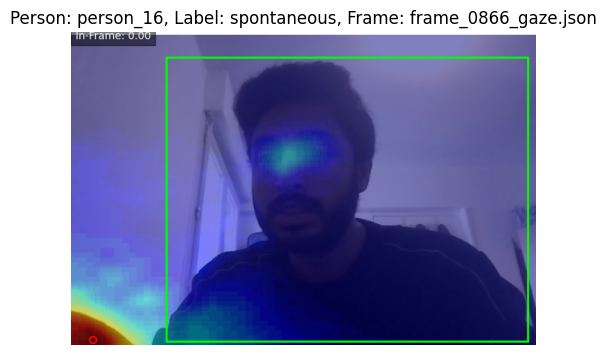

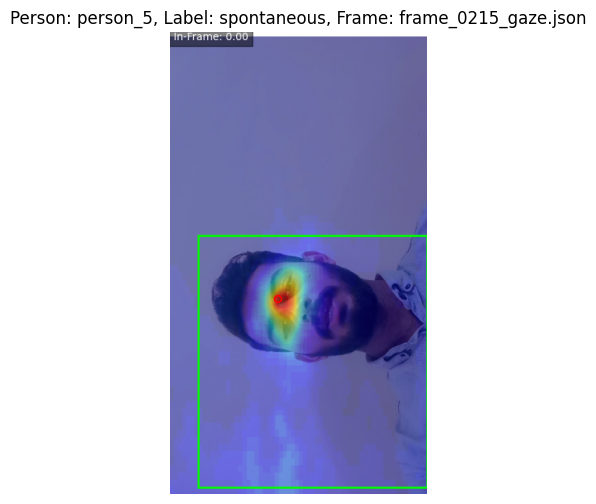

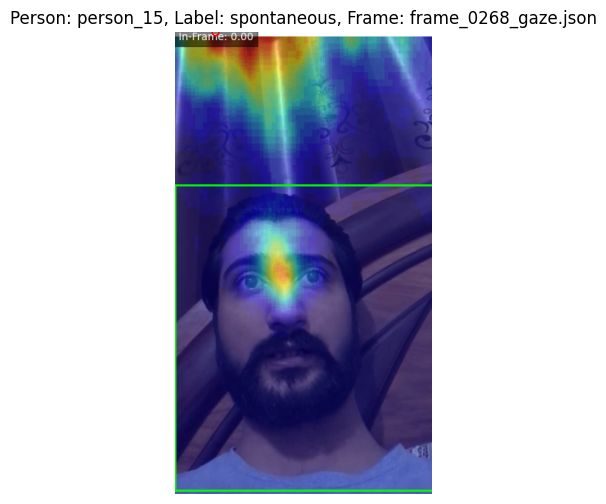

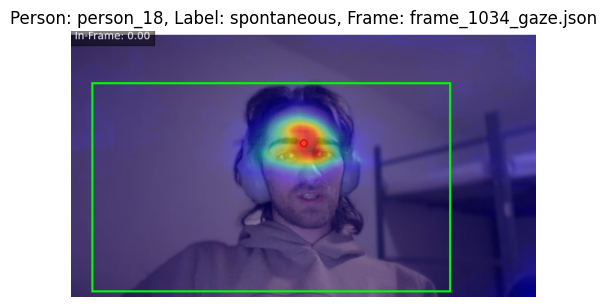

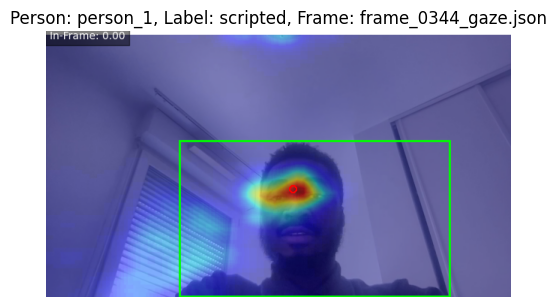

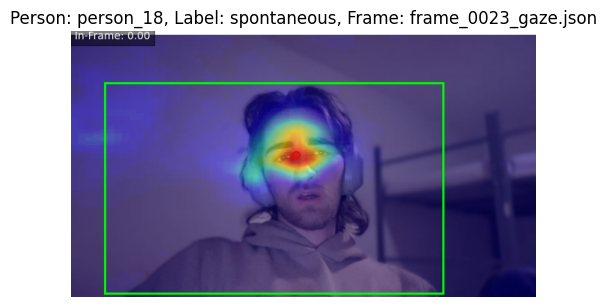

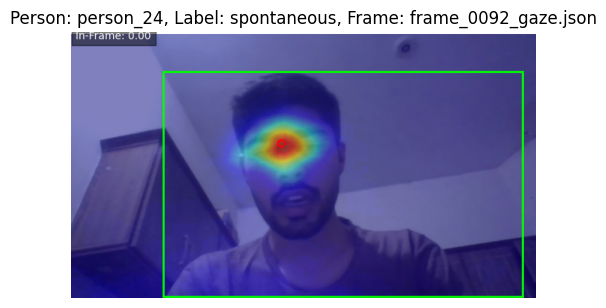

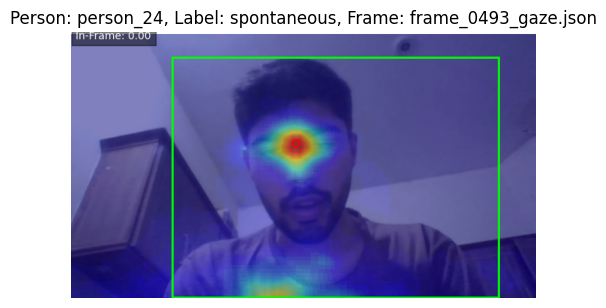

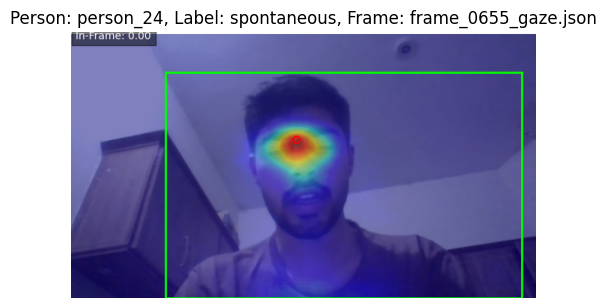

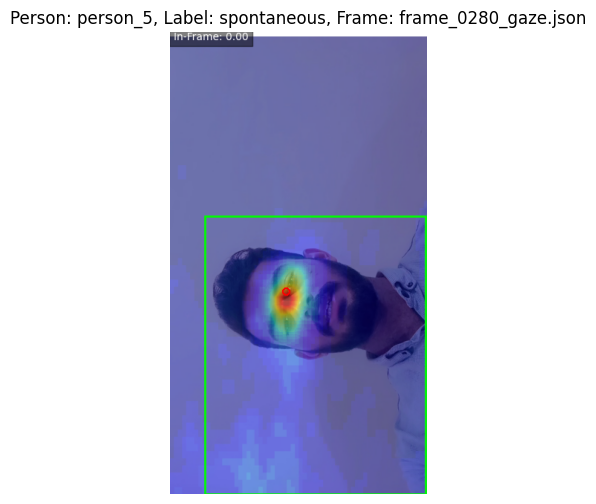

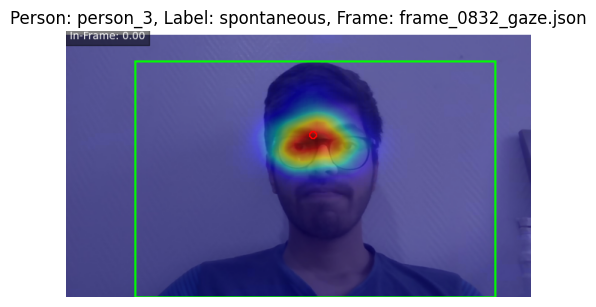

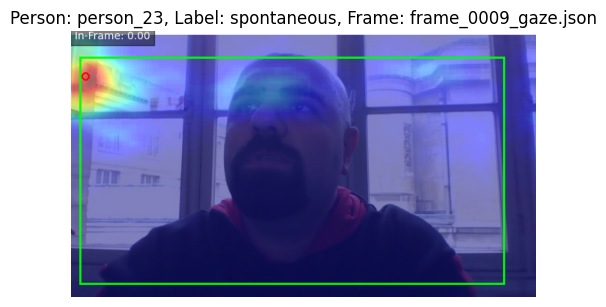

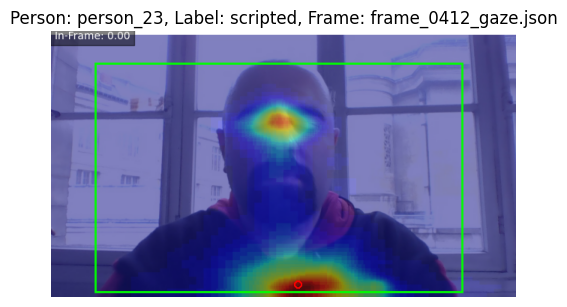

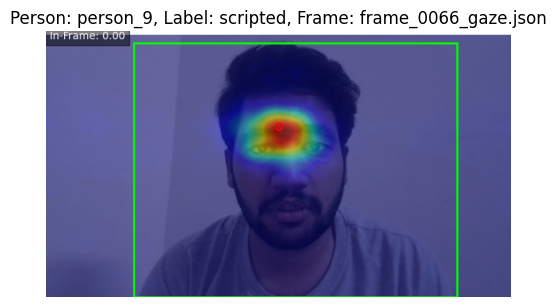

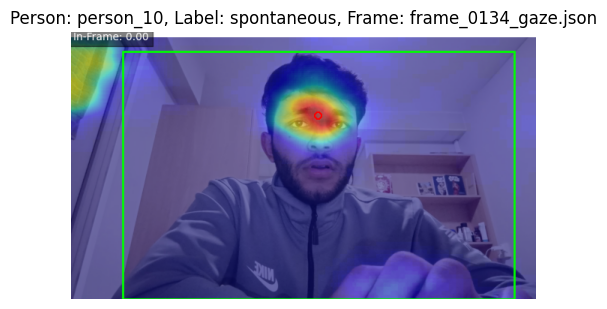

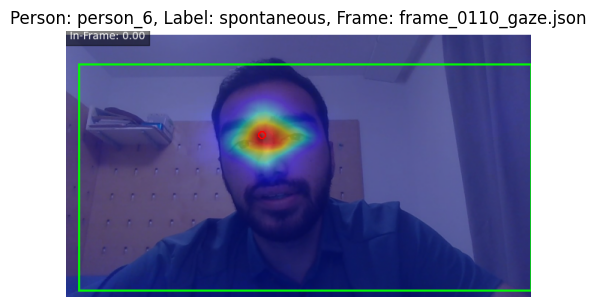

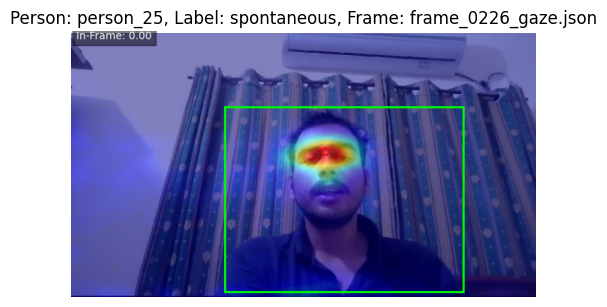

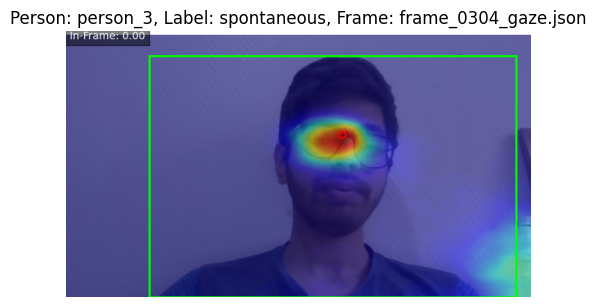

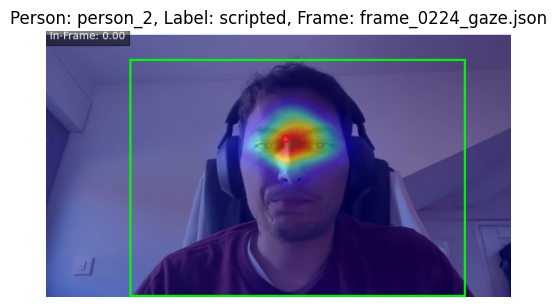

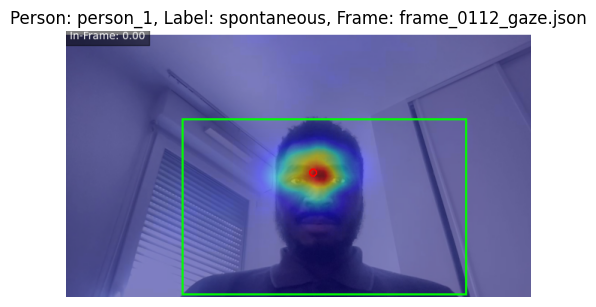

In [7]:
import os
import random
import pandas as pd
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# 1. Load extracted gaze coordinates from CSV
csv_path = r"C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_coordinates.csv"  # Update as needed
df = pd.read_csv(csv_path)

# Select 20 random samples from the DataFrame
random_samples = df.sample(n=20)

def derive_heatmap_image_path(frame_json_path):
    """
    Derive the heatmap image path from the JSON file path.
    Example structure:
      ...\gaze_output\person_x\scripted\data\frame_0000_gaze.json
    => ...\gaze_output\person_x\scripted\heatmaps\frame_0000_heatmap.png
    """
    # Replace '\data\' with '\heatmaps\' and change '_gaze.json' → '_heatmap.png'
    heatmap_path = frame_json_path.replace(os.sep + "data" + os.sep, os.sep + "heatmaps" + os.sep)
    heatmap_path = heatmap_path.replace("_gaze.json", "_heatmap.png")
    return heatmap_path

for idx, row in random_samples.iterrows():
    person = row["person_id"]
    label = row["label"]
    frame_file = row["frame_file"]
    gaze_x = row["gaze_x"]
    gaze_y = row["gaze_y"]

    # Retrieve the JSON path from CSV or reconstruct it
    frame_json_path = row.get("frame_path")
    if pd.isna(frame_json_path) or not frame_json_path:
        # If CSV doesn't store frame_path, reconstruct a guess:
        frame_json_path = os.path.join(
            r"C:\Users\muham\PycharmProjects\gazelle\gaze_output",
            person, label, "data", frame_file
        )

    # 2. Derive the heatmap image path from the JSON path
    heatmap_image_path = derive_heatmap_image_path(frame_json_path)

    # 3. Open the heatmap image
    if not os.path.exists(heatmap_image_path):
        print(f"Heatmap image not found for {heatmap_image_path}")
        continue
    image = Image.open(heatmap_image_path).convert("RGB")

    # Check image size to see if it's 64×64 or larger
    width, height = image.size

    # 4. If the heatmap is bigger than 64×64, scale coordinates
    # e.g. if it's 640×640, multiply by 10
    scale_x = width / 64.0
    scale_y = height / 64.0

    scaled_x = gaze_x * scale_x
    scaled_y = gaze_y * scale_y

    # 5. Draw a red circle at the gaze location on the heatmap
    draw = ImageDraw.Draw(image)
    radius = 5
    leftUpPoint = (scaled_x - radius, scaled_y - radius)
    rightDownPoint = (scaled_x + radius, scaled_y + radius)
    draw.ellipse([leftUpPoint, rightDownPoint], outline="red", width=2)

    # 6. Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Person: {person}, Label: {label}, Frame: {frame_file}")
    plt.axis('off')
    plt.show()


In [1]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False, max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5)

# Define eye landmarks (MediaPipe Face Mesh has 468 landmarks)
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]  # Left eye landmarks
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]  # Right eye landmarks

def eye_aspect_ratio(eye_landmarks):
    """
    Calculate the Eye Aspect Ratio (EAR) for a set of eye landmarks.
    EAR is the ratio of the vertical distance to the horizontal distance between eye landmarks.
    """
    # Vertical distances
    A = np.linalg.norm(eye_landmarks[1] - eye_landmarks[5])
    B = np.linalg.norm(eye_landmarks[2] - eye_landmarks[4])
    # Horizontal distance
    C = np.linalg.norm(eye_landmarks[0] - eye_landmarks[3])
    ear = (A + B) / (2.0 * C)
    return ear

def detect_blinks(video_path, ear_threshold=0.21, consecutive_frames=3):
    """
    Detect blinks in a video using facial landmarks and Eye Aspect Ratio (EAR).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return 0, 0, []

    # Get FPS and total frames
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        print(f"Warning: FPS is 0 for {video_path}. Using default FPS=30.")
        fps = 30  # Default FPS

    blink_count = 0
    frame_count = 0
    blink_frames = []
    ear_history = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print(f"End of video or frame read error at frame {frame_count}.")
            break

        frame_count += 1
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)

        if results.multi_face_landmarks:
            try:
                landmarks = results.multi_face_landmarks[0].landmark
                left_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in LEFT_EYE_INDICES])
                right_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in RIGHT_EYE_INDICES])

                # Calculate EAR for both eyes
                left_ear = eye_aspect_ratio(left_eye)
                right_ear = eye_aspect_ratio(right_eye)
                ear = (left_ear + right_ear) / 2.0
                ear_history.append(ear)

                # Detect blink
                if ear < ear_threshold:
                    blink_frames.append(frame_count)
                    if len(blink_frames) >= consecutive_frames:
                        blink_count += 1
                        blink_frames = []
                else:
                    blink_frames = []

            except Exception as e:
                print(f"Error processing frame {frame_count}: {e}")
                continue

        # Display EAR on frame (optional)
        cv2.putText(frame, f"EAR: {ear:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        cv2.imshow("Frame", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Video playback stopped by user.")
            break

    cap.release()
    cv2.destroyAllWindows()

    # Calculate blink rate (blinks per minute)
    total_time = frame_count / fps
    if total_time == 0:
        print(f"Warning: Total time is 0 for {video_path}. Cannot calculate blink rate.")
        blink_rate = 0
    else:
        blink_rate = blink_count / (total_time / 60)  # Blinks per minute

    return blink_count, blink_rate, ear_history

# Example Usage
video_path = r"C:\Users\muham\OneDrive\Pictures\Camera Roll\WIN_20250126_15_07_00_Pro.mp4"
blink_count, blink_rate, ear_history = detect_blinks(video_path)
print(f"Blink Count: {blink_count}")
print(f"Blink Rate: {blink_rate:.2f} blinks per minute")

End of video or frame read error at frame 2777.
Blink Count: 3
Blink Rate: 1.94 blinks per minute


In [3]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False, max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5)

# Define eye landmarks (MediaPipe Face Mesh has 468 landmarks)
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]  # Left eye landmarks
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]  # Right eye landmarks

def eye_aspect_ratio(eye_landmarks):
    """
    Calculate the Eye Aspect Ratio (EAR) for a set of eye landmarks.
    EAR is the ratio of the vertical distance to the horizontal distance between eye landmarks.
    """
    # Vertical distances
    A = np.linalg.norm(eye_landmarks[1] - eye_landmarks[5])
    B = np.linalg.norm(eye_landmarks[2] - eye_landmarks[4])
    # Horizontal distance
    C = np.linalg.norm(eye_landmarks[0] - eye_landmarks[3])
    ear = (A + B) / (2.0 * C)
    return ear

def detect_blinks_realtime(ear_threshold=0.21, consecutive_frames=3):
    """
    Detect blinks in real-time using a webcam.
    """
    # Initialize webcam
    cap = cv2.VideoCapture(0)  # 0 for default webcam
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return

    blink_count = 0
    frame_count = 0
    blink_frames = []
    ear_history = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame from webcam.")
            break

        frame_count += 1
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)

        if results.multi_face_landmarks:
            try:
                landmarks = results.multi_face_landmarks[0].landmark
                left_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in LEFT_EYE_INDICES])
                right_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in RIGHT_EYE_INDICES])

                # Calculate EAR for both eyes
                left_ear = eye_aspect_ratio(left_eye)
                right_ear = eye_aspect_ratio(right_eye)
                ear = (left_ear + right_ear) / 2.0
                ear_history.append(ear)

                # Detect blink
                if ear < ear_threshold:
                    blink_frames.append(frame_count)
                    if len(blink_frames) >= consecutive_frames:
                        blink_count += 1
                        blink_frames = []
                else:
                    blink_frames = []

            except Exception as e:
                print(f"Error processing frame {frame_count}: {e}")
                continue

        # Display EAR on frame
        cv2.putText(frame, f"EAR: {ear:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        cv2.putText(frame, f"Blinks: {blink_count}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow("Real-time Blink Detection", frame)

        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Real-time blink detection stopped by user.")
            break

    # Release webcam and close windows
    cap.release()
    cv2.destroyAllWindows()

    # Calculate blink rate (blinks per minute)
    if frame_count > 0:
        total_time = frame_count / 30  # Assuming 30 FPS for webcam
        blink_rate = blink_count / (total_time / 60)  # Blinks per minute
        print(f"Total Blinks: {blink_count}")
        print(f"Blink Rate: {blink_rate:.2f} blinks per minute")
    else:
        print("No frames processed.")

# Run real-time blink detection
detect_blinks_realtime()

Real-time blink detection stopped by user.
Total Blinks: 36
Blink Rate: 76.60 blinks per minute


In [2]:
import os
import csv
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False,
                                 max_num_faces=1,
                                 refine_landmarks=True,
                                 min_detection_confidence=0.5)

# Define eye landmarks
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]

def eye_aspect_ratio(eye_landmarks):
    """Calculate Eye Aspect Ratio (EAR) for given eye landmarks."""
    vertical1 = np.linalg.norm(eye_landmarks[1] - eye_landmarks[5])
    vertical2 = np.linalg.norm(eye_landmarks[2] - eye_landmarks[4])
    horizontal = np.linalg.norm(eye_landmarks[0] - eye_landmarks[3])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def detect_blinks(video_path, ear_threshold=0.21, consecutive_frames=3):
    """Detect blinks in a video using facial landmarks and EAR."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0, 0  # Return zeros if video can't be opened

    fps = cap.get(cv2.CAP_PROP_FPS) or 30  # Default to 30 FPS if unavailable
    blink_count = 0
    frame_counter = 0
    consecutive_blink_frames = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_counter += 1
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(frame_rgb)

        ear = None
        if results.multi_face_landmarks:
            try:
                landmarks = results.multi_face_landmarks[0].landmark
                left_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in LEFT_EYE_INDICES])
                right_eye = np.array([(landmarks[i].x, landmarks[i].y) for i in RIGHT_EYE_INDICES])

                ear_left = eye_aspect_ratio(left_eye)
                ear_right = eye_aspect_ratio(right_eye)
                ear = (ear_left + ear_right) / 2.0
            except Exception as e:
                continue

        # Blink detection logic
        if ear and ear < ear_threshold:
            consecutive_blink_frames += 1
            if consecutive_blink_frames >= consecutive_frames:
                blink_count += 1
                consecutive_blink_frames = 0  # Reset counter after blink detection
        else:
            consecutive_blink_frames = 0  # Reset if eyes open or face not detected

    cap.release()

    # Calculate blink rate (blinks per minute)
    duration = frame_counter / fps
    blink_rate = blink_count / (duration / 60) if duration > 0 else 0

    return blink_count, round(blink_rate, 2)

def process_videos_folder(input_folder, output_csv):
    """Process all videos in a folder and save results to CSV."""
    video_extensions = ('.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv')
    video_files = [f for f in os.listdir(input_folder)
                  if os.path.isfile(os.path.join(input_folder, f))
                  and f.lower().endswith(video_extensions)]

    results = []
    for video_file in video_files:
        video_path = os.path.join(input_folder, video_file)
        print(f"Processing: {video_file}")
        blink_count, blink_rate = detect_blinks(video_path)
        results.append([video_file, blink_count, blink_rate])

    # Write results to CSV
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Video File', 'Blink Count', 'Blink Rate (bpm)'])
        writer.writerows(results)

    print(f"Processed {len(results)} videos. Results saved to {output_csv}")

# Example usage
if __name__ == "__main__":
    input_folder = r"C:\Users\muham\PycharmProjects\Project_eye_gaze\videos"
    output_csv = "blink_results.csv"
    process_videos_folder(input_folder, output_csv)

Processing: 10R.mp4
Processing: 10S.mp4
Processing: 11R.mp4
Processing: 11S.mp4
Processing: 12R.mp4
Processing: 13R.mp4
Processing: 13S.mp4
Processing: 14R.mp4
Processing: 14S.mp4
Processing: 15R.mp4
Processing: 15S.mp4
Processing: 16R.mp4
Processing: 16S.mp4
Processing: 17R.mp4
Processing: 17S.mp4
Processing: 18R.mp4
Processing: 18S.mp4
Processing: 19R.mp4
Processing: 19S.mp4
Processing: 1R.mp4
Processing: 1S.mp4
Processing: 20R.mp4
Processing: 20S.mp4
Processing: 21R.mp4
Processing: 21S.mp4
Processing: 22R.mp4
Processing: 22S.mp4
Processing: 23R.mp4
Processing: 23S.mp4
Processing: 24R.mp4
Processing: 24S.mp4
Processing: 25R.mp4
Processing: 25S.mp4
Processing: 26R.mp4
Processing: 26S.mp4
Processing: 27R.mp4
Processing: 27S.mp4
Processing: 28R.mp4
Processing: 28S.mp4
Processing: 2R.mp4
Processing: 2S.mp4
Processing: 3R.mp4
Processing: 3S.mp4
Processing: 4R.mp4
Processing: 4S.mp4
Processing: 5R.mp4
Processing: 5S.mp4
Processing: 6R.mp4
Processing: 6S.mp4
Processing: 7R.mp4
Processing: 7

In [3]:
import os
import csv
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False,
                                 max_num_faces=1,
                                 refine_landmarks=True,
                                 min_detection_confidence=0.5,
                                 min_tracking_confidence=0.5)

# Updated eye landmarks (MediaPipe 0.10.1+)
LEFT_EYE_INDICES = [362, 385, 387, 263, 373, 380]
RIGHT_EYE_INDICES = [33, 160, 158, 133, 153, 144]

def eye_aspect_ratio(eye_landmarks):
    """Improved EAR calculation with error handling"""
    try:
        vertical1 = np.linalg.norm(eye_landmarks[1] - eye_landmarks[5])
        vertical2 = np.linalg.norm(eye_landmarks[2] - eye_landmarks[4])
        horizontal = np.linalg.norm(eye_landmarks[0] - eye_landmarks[3])
        return (vertical1 + vertical2) / (2.0 * horizontal)
    except Exception as e:
        return None

def detect_blinks(video_path, ear_threshold=0.18, consecutive_frames=2, debug=False):
    """Enhanced blink detection with visualization and debugging"""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0, 0, []

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    blink_count = 0
    ear_history = []
    consecutive_low_ear = 0
    in_blink = False

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(frame_rgb)

        ear = None
        if results.multi_face_landmarks:
            try:
                landmarks = results.multi_face_landmarks[0].landmark

                # Get eye coordinates in image space
                left_eye = np.array([(landmarks[i].x * width, landmarks[i].y * height)
                                   for i in LEFT_EYE_INDICES])
                right_eye = np.array([(landmarks[i].x * width, landmarks[i].y * height)
                                    for i in RIGHT_EYE_INDICES])

                ear_left = eye_aspect_ratio(left_eye)
                ear_right = eye_aspect_ratio(right_eye)

                if ear_left and ear_right:
                    ear = (ear_left + ear_right) / 2.0
                    ear_history.append(ear)

                    # Blink state machine
                    if ear < ear_threshold:
                        consecutive_low_ear += 1
                        if not in_blink and consecutive_low_ear >= consecutive_frames:
                            blink_count += 1
                            in_blink = True
                    else:
                        consecutive_low_ear = 0
                        in_blink = False

                # Visual debug
                if debug:
                    for point in left_eye:
                        cv2.circle(frame, tuple(map(int, point)), 1, (0,255,0), -1)
                    for point in right_eye:
                        cv2.circle(frame, tuple(map(int, point)), 1, (0,255,0), -1)
                    cv2.putText(frame, f"EAR: {ear:.2f}", (10, 30),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
                    cv2.imshow("Debug", frame)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        break

            except Exception as e:
                continue

    cap.release()
    cv2.destroyAllWindows()

    # Calculate blink rate
    duration = len(ear_history) / fps
    blink_rate = blink_count / (duration / 60) if duration > 0 else 0

    return blink_count, round(blink_rate, 2), ear_history

def process_videos_folder(input_folder, output_csv, debug=False):
    """Enhanced processing with EAR visualization"""
    video_files = [f for f in os.listdir(input_folder)
                  if f.lower().endswith(('.mp4', '.avi', '.mov'))]

    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Video File', 'Blink Count', 'Blink Rate (bpm)', 'EAR Plot'])

        for video_file in video_files:
            video_path = os.path.join(input_folder, video_file)
            print(f"\nProcessing: {video_file}")

            blink_count, blink_rate, ear_history = detect_blinks(
                video_path,
                ear_threshold=0.18,  # Lower threshold for subtle blinks
                consecutive_frames=2,  # Fewer frames for faster blinks
                debug=debug
            )

            # Generate EAR plot
            plot_path = f"ear_plots/{video_file}_ear.png"
            plt.figure(figsize=(10, 4))
            plt.plot(ear_history)
            plt.axhline(y=0.18, color='r', linestyle='--')
            plt.title(f"EAR History - {video_file}")
            plt.ylabel("EAR")
            plt.xlabel("Frames")
            plt.savefig(plot_path)
            plt.close()

            writer.writerow([video_file, blink_count, blink_rate, plot_path])

    print(f"\nProcessing complete. Results saved to {output_csv}")

# Usage
if __name__ == "__main__":
    input_folder = r"C:\Users\muham\PycharmProjects\Project_eye_gaze\videos"
    output_csv = "blink_results_1.csv"

    # Create directory for EAR plots
    os.makedirs("ear_plots", exist_ok=True)

    # Set debug=True to visualize processing
    process_videos_folder(input_folder, output_csv, debug=False)


Processing: 10R.mp4

Processing: 10S.mp4

Processing: 11R.mp4

Processing: 11S.mp4

Processing: 12R.mp4

Processing: 13R.mp4

Processing: 13S.mp4

Processing: 14R.mp4

Processing: 14S.mp4

Processing: 15R.mp4

Processing: 15S.mp4

Processing: 16R.mp4

Processing: 16S.mp4

Processing: 17R.mp4

Processing: 17S.mp4

Processing: 18R.mp4

Processing: 18S.mp4

Processing: 19R.mp4

Processing: 19S.mp4

Processing: 1R.mp4

Processing: 1S.mp4

Processing: 20R.mp4

Processing: 20S.mp4

Processing: 21R.mp4

Processing: 21S.mp4

Processing: 22R.mp4

Processing: 22S.mp4

Processing: 23R.mp4

Processing: 23S.mp4

Processing: 24R.mp4

Processing: 24S.mp4

Processing: 25R.mp4

Processing: 25S.mp4

Processing: 26R.mp4

Processing: 26S.mp4

Processing: 27R.mp4

Processing: 27S.mp4

Processing: 28R.mp4

Processing: 28S.mp4

Processing: 2R.mp4

Processing: 2S.mp4

Processing: 3R.mp4

Processing: 3S.mp4

Processing: 4R.mp4

Processing: 4S.mp4

Processing: 5R.mp4

Processing: 5S.mp4

Processing: 6R.mp4

Pr

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

# Load datasets
gaze_features = pd.read_csv(r"C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_features.csv")
blink_results = pd.read_csv(r"C:\Users\muham\PycharmProjects\gazelle\scripts\blink_results.csv" )

# Merge datasets on 'person_id' and 'label'
merged_data = pd.merge(gaze_features, blink_results[['person_id', 'label', 'blink_count', 'blink_rate_bpm']], on=['person_id', 'label'])

# Encode labels
le = LabelEncoder()
merged_data['label'] = le.fit_transform(merged_data['label'])

# Prepare features and target
X = merged_data.drop(columns=['person_id', 'label'])
y = merged_data['label']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models and hyperparameters
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(kernel='rbf', probability=True),
    'KNN': KNeighborsClassifier()
}

# Hyperparameter tuning for SVM
param_grid_svm = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
grid_svm = GridSearchCV(models['SVM'], param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)
models['SVM'] = grid_svm.best_estimator_

# Model evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred):.4f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
    print(f'ROC AUC: {roc_auc_score(y_test, y_pred):.4f}')
    print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}')

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'\n{name} Evaluation:')
    evaluate_model(model, X_test, y_test)

# Recommend best model for small dataset
best_model = max(models, key=lambda x: accuracy_score(y_test, models[x].predict(X_test)))
print(f'\nBest model for small dataset: {best_model}')



LogisticRegression Evaluation:
Accuracy: 0.6364
Precision: 0.6667
Recall: 0.6667
F1 Score: 0.6667
ROC AUC: 0.6333
Confusion Matrix:
 [[3 2]
 [2 4]]

RandomForest Evaluation:
Accuracy: 0.3636
Precision: 0.3333
Recall: 0.1667
F1 Score: 0.2222
ROC AUC: 0.3833
Confusion Matrix:
 [[3 2]
 [5 1]]

SVM Evaluation:
Accuracy: 0.6364
Precision: 0.6667
Recall: 0.6667
F1 Score: 0.6667
ROC AUC: 0.6333
Confusion Matrix:
 [[3 2]
 [2 4]]

KNN Evaluation:
Accuracy: 0.3636
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.4000
Confusion Matrix:
 [[4 1]
 [6 0]]

Best model for small dataset: LogisticRegression


### Data Integration

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33109 entries, 0 to 33108
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gaze_x                33109 non-null  int64  
 1   gaze_y                33109 non-null  int64  
 2   inout_score           33109 non-null  float64
 3   in_frame              33109 non-null  bool   
 4   head_box_xmin         33109 non-null  float64
 5   head_box_ymin         33109 non-null  float64
 6   head_box_xmax         33109 non-null  float64
 7   head_box_ymax         33109 non-null  float64
 8   distance_from_center  33109 non-null  float64
 9   json_path             33109 non-null  object 
 10  person_id             33109 non-null  object 
 11  label                 33109 non-null  object 
 12  frame_file            33109 non-null  object 
dtypes: bool(1), float64(6), int64(2), object(4)
memory usage: 3.1+ MB
None
   gaze_x  gaze_y  inout_score  in_frame  head_box

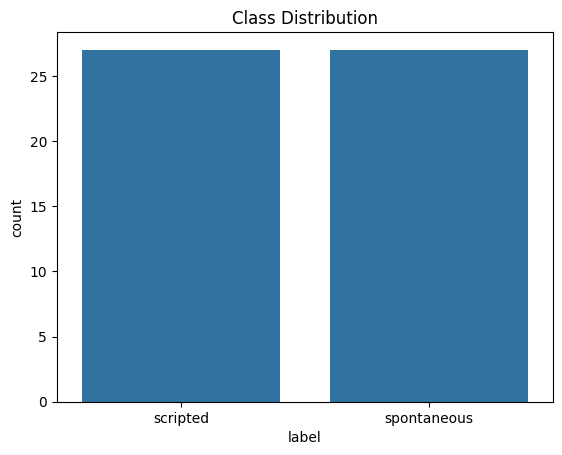

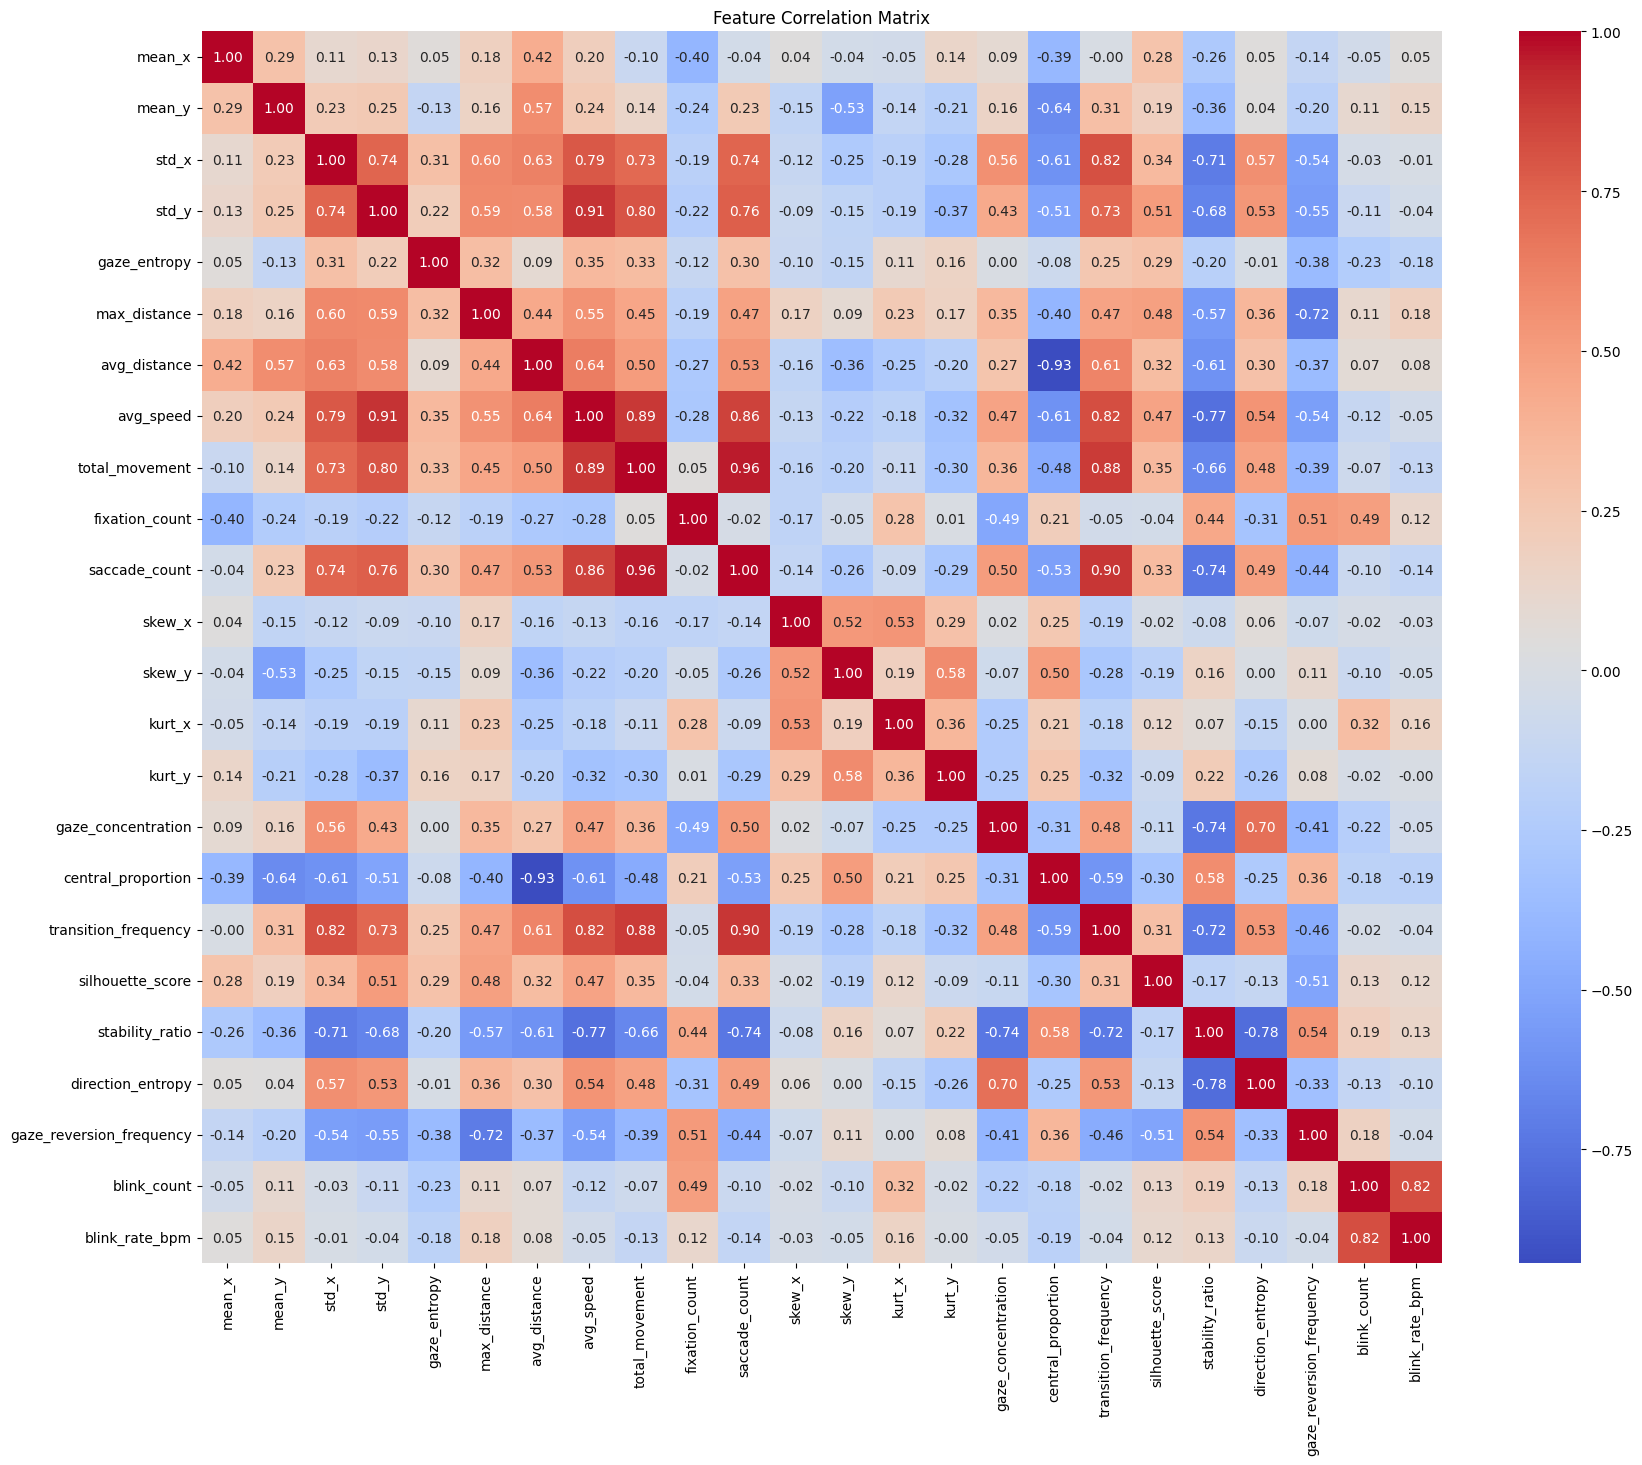

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
gaze_coordinates_path = r'C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_coordinates.csv'
gaze_features_path = r"C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_features.csv"
blink_results_path = r"C:\Users\muham\PycharmProjects\gazelle\scripts\blink_results.csv"

gaze_coordinates = pd.read_csv(gaze_coordinates_path)
gaze_features = pd.read_csv(gaze_features_path)
blink_results = pd.read_csv(blink_results_path)

# Merge gaze_features and blink_results on 'person_id' and 'label'
merged_data = pd.merge(gaze_features, blink_results, on=['person_id', 'label'], how='inner')

# Display basic information and first few rows of each dataset
print(gaze_coordinates.info())
print(gaze_coordinates.head())

print(gaze_features.info())
print(gaze_features.head())

print(blink_results.info())
print(blink_results.head())

# Display the first few rows of the merged dataset
print(merged_data.head())

# Exploratory Data Analysis (EDA)

# Basic statistics
print(merged_data.describe())

# Check class distribution
sns.countplot(x='label', data=merged_data)
plt.title('Class Distribution')
plt.show()

# Correlation matrix - only numeric columns
numeric_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = merged_data[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


### Data Integration and Preparation

In [5]:
# Merge gaze_features and blink_results on 'person_id' and 'label'
merged_data = pd.merge(gaze_features, blink_results, on=['person_id', 'label'], how='inner')
# Identify numeric columns
numeric_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_data['label_encoded'] = le.fit_transform(merged_data['label'])  # 0: scripted, 1: spontaneous


### DExploratory Data Analysis (EDA)

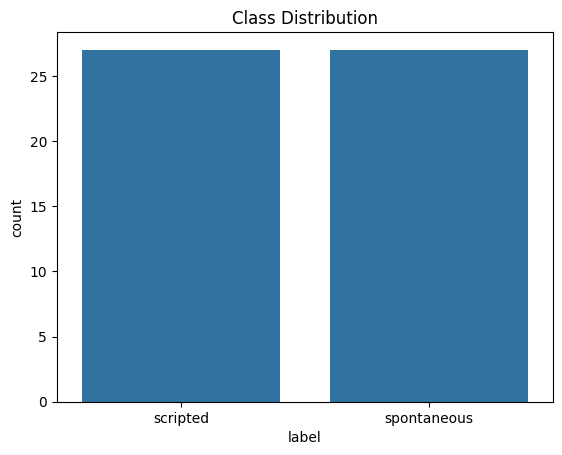

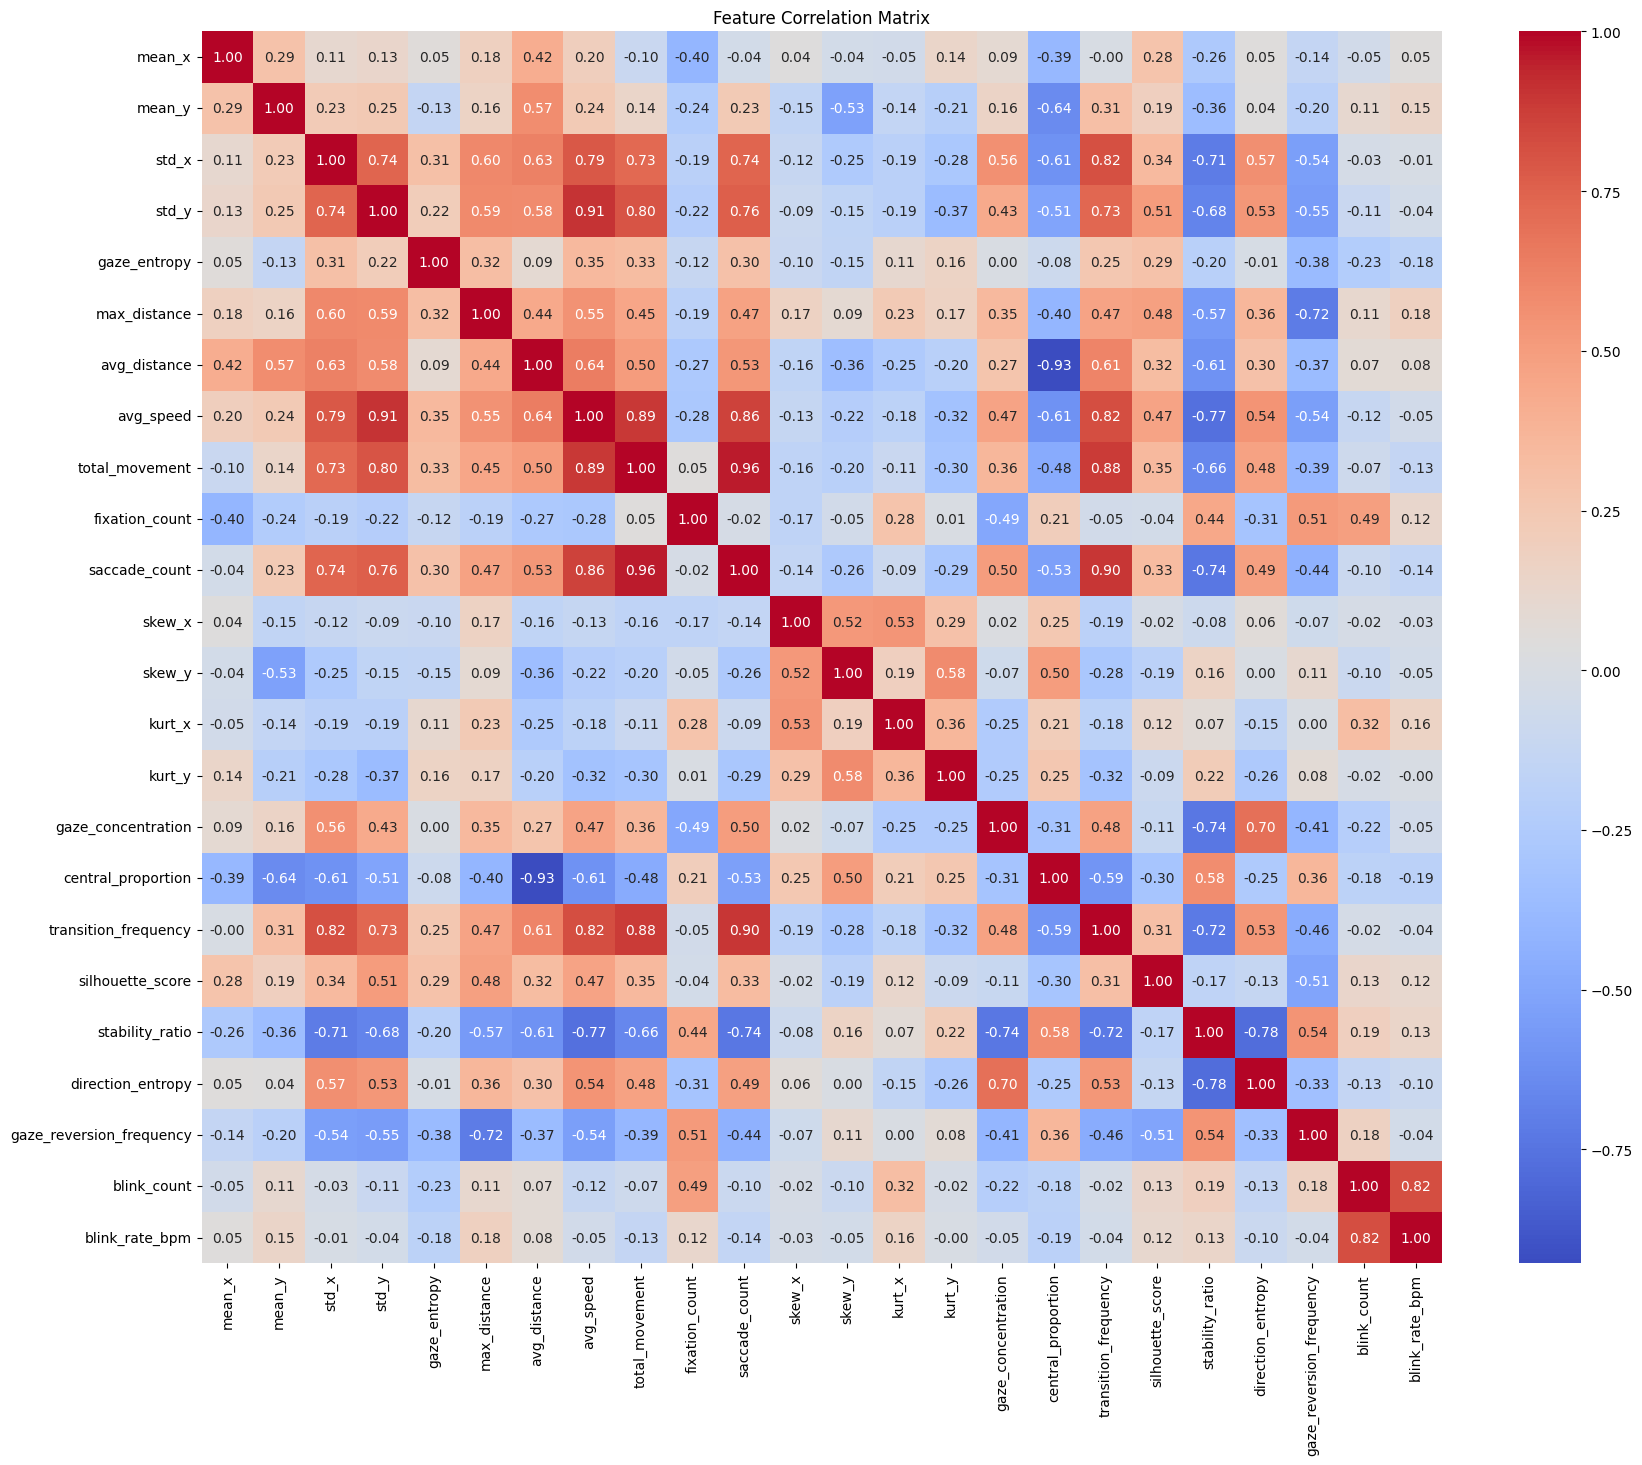

In [6]:
sns.countplot(x='label', data=merged_data)
plt.title('Class Distribution')
plt.show()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


###  Handling Small Dataset Challenges

In [7]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


b. Regularization
Opt for models that include regularization parameters to prevent overfitting, such as Logistic Regression or Support Vector Machines (SVM).

c. Data Augmentation / Synthetic Data Generation
Consider generating synthetic samples to augment your dataset, especially if classes are imbalanced.

In [8]:
from imblearn.over_sampling import SMOTE

# Check class distribution
print(merged_data['label_encoded'].value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(merged_data.drop(['person_id', 'label', 'label_encoded'], axis=1), merged_data['label_encoded'])

print(pd.Series(y_resampled).value_counts())


label_encoded
0    27
1    27
Name: count, dtype: int64
label_encoded
0    27
1    27
Name: count, dtype: int64


C:\Users\muham\PycharmProjects\gazelle\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\muham\PycharmProjects\gazelle\.venv\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [9]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Define feature matrix X and target vector y
X = merged_data.drop(['person_id', 'label', 'label_encoded'], axis=1)
y = merged_data['label_encoded']

# Initialize SVM with regularization
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# Create a pipeline with scaling and classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', svm_clf)
])

# Evaluate using cross-validation
scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
print(f"SVM Cross-Validation Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")


SVM Cross-Validation Accuracy: 0.63 ± 0.01


In [10]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression with regularization
lr_clf = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)

# Create a pipeline with scaling and classifier
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lr_clf)
])

# Evaluate using cross-validation
scores_lr = cross_val_score(pipeline_lr, X, y, cv=skf, scoring='accuracy')
print(f"Logistic Regression Cross-Validation Accuracy: {scores_lr.mean():.2f} ± {scores_lr.std():.2f}")


Logistic Regression Cross-Validation Accuracy: 0.59 ± 0.09


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with limited depth
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Create a pipeline with scaling and classifier
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', rf_clf)
])

# Evaluate using cross-validation
scores_rf = cross_val_score(pipeline_rf, X, y, cv=skf, scoring='accuracy')
print(f"Random Forest Cross-Validation Accuracy: {scores_rf.mean():.2f} ± {scores_rf.std():.2f}")


Random Forest Cross-Validation Accuracy: 0.63 ± 0.06


              precision    recall  f1-score   support

    Scripted       0.63      0.63      0.63        27
 Spontaneous       0.63      0.63      0.63        27

    accuracy                           0.63        54
   macro avg       0.63      0.63      0.63        54
weighted avg       0.63      0.63      0.63        54



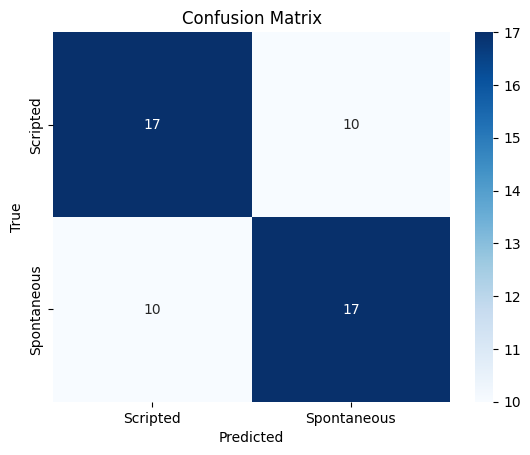

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Example with SVM
y_pred = cross_val_predict(pipeline, X, y, cv=skf)

# Classification Report
print(classification_report(y, y_pred, target_names=['Scripted', 'Spontaneous']))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Scripted', 'Spontaneous'], yticklabels=['Scripted', 'Spontaneous'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


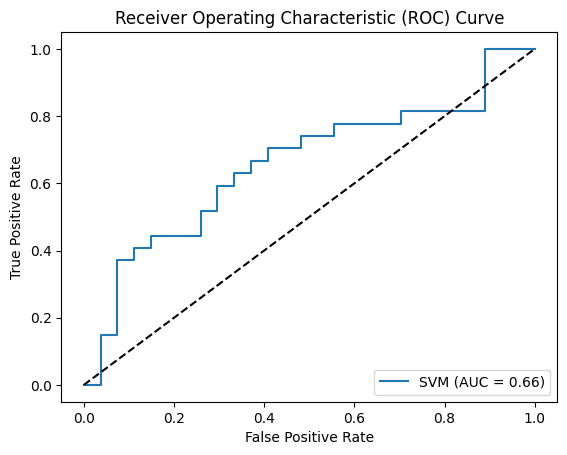

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

# Compute decision function scores
y_scores = cross_val_predict(pipeline, X, y, cv=skf, method='decision_function')

# Calculate ROC AUC
auc = roc_auc_score(y, y_scores)
fpr, tpr, thresholds = roc_curve(y, y_scores)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [14]:
from imblearn.over_sampling import SMOTE

# Check class distribution
print(y.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print(pd.Series(y_resampled).value_counts())


label_encoded
0    27
1    27
Name: count, dtype: int64
label_encoded
0    27
1    27
Name: count, dtype: int64


C:\Users\muham\PycharmProjects\gazelle\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\muham\PycharmProjects\gazelle\.venv\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [15]:
# Update X and y with resampled data
X_augmented = X_resampled
y_augmented = y_resampled

# Re-initialize cross-validation
skf_augmented = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Example with Logistic Regression
scores_lr_augmented = cross_val_score(pipeline_lr, X_augmented, y_augmented, cv=skf_augmented, scoring='accuracy')
print(f"Logistic Regression (SMOTE) Cross-Validation Accuracy: {scores_lr_augmented.mean():.2f} ± {scores_lr_augmented.std():.2f}")


Logistic Regression (SMOTE) Cross-Validation Accuracy: 0.59 ± 0.09


In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
scores = scores.sort_values(by='Score', ascending=False)
print(scores)

# Select top N features
top_n = 15
selected_features = scores.head(top_n)['Feature'].tolist()
X_selected = X[selected_features]


                     Feature      Score
23            blink_rate_bpm  16.245138
22               blink_count  11.462427
20         direction_entropy   3.570123
13                    kurt_x   2.731979
3                      std_y   2.308075
10             saccade_count   2.168695
15        gaze_concentration   1.275356
8             total_movement   1.204711
19           stability_ratio   1.036292
7                  avg_speed   0.948085
6               avg_distance   0.912255
0                     mean_x   0.851254
2                      std_x   0.825292
14                    kurt_y   0.609709
21  gaze_reversion_frequency   0.568851
17      transition_frequency   0.440434
9             fixation_count   0.436420
16        central_proportion   0.195550
4               gaze_entropy   0.042007
1                     mean_y   0.039885
11                    skew_x   0.032256
18          silhouette_score   0.022333
5               max_distance   0.019355
12                    skew_y   0.003116


Selected Features:
Index(['mean_x', 'std_x', 'std_y', 'avg_distance', 'avg_speed',
       'total_movement', 'saccade_count', 'kurt_x', 'kurt_y',
       'gaze_concentration', 'stability_ratio', 'direction_entropy',
       'gaze_reversion_frequency', 'blink_count', 'blink_rate_bpm'],
      dtype='object')
Classification Report:
              precision    recall  f1-score   support

    Scripted       0.72      0.85      0.78        27
 Spontaneous       0.82      0.67      0.73        27

    accuracy                           0.76        54
   macro avg       0.77      0.76      0.76        54
weighted avg       0.77      0.76      0.76        54



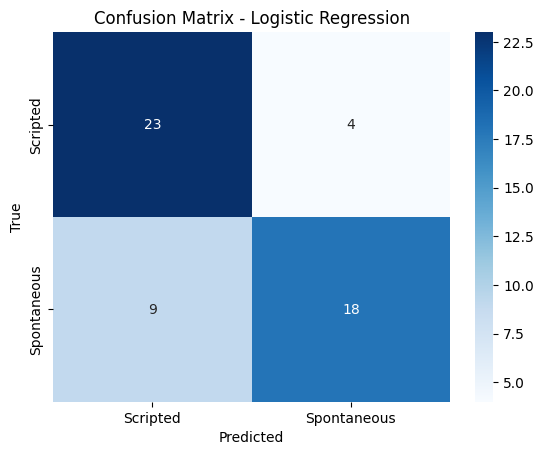

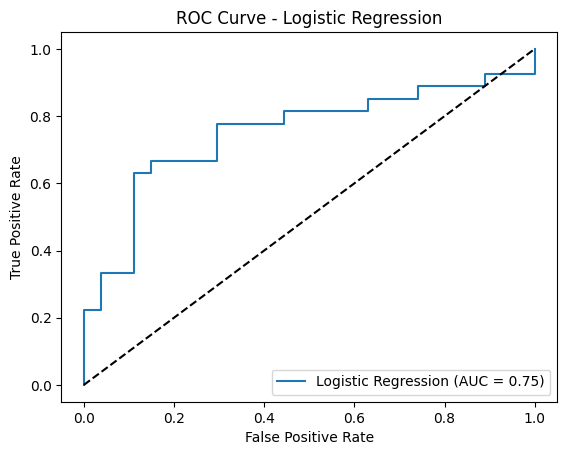

In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Load and merge datasets
gaze_features = pd.read_csv(r"C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_features.csv")
blink_results = pd.read_csv(r"C:\Users\muham\PycharmProjects\gazelle\scripts\blink_results.csv"
)
merged_data = pd.merge(gaze_features, blink_results, on=['person_id', 'label'], how='inner')

# Encode target variable
le = LabelEncoder()
merged_data['label_encoded'] = le.fit_transform(merged_data['label'])  # 0: scripted, 1: spontaneous

# Define features and target
X = merged_data.drop(['person_id', 'label', 'label_encoded'], axis=1)
y = merged_data['label_encoded']

# Feature Selection: Select top 15 features
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

# Create a pipeline with scaling and Logistic Regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42))
])

# Define cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get predictions
y_pred = cross_val_predict(pipeline_lr, X_selected, y, cv=skf)

# Classification Report
print("Classification Report:")
print(classification_report(y, y_pred, target_names=['Scripted', 'Spontaneous']))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Scripted', 'Spontaneous'], yticklabels=['Scripted', 'Spontaneous'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC Curve and AUC
y_scores = cross_val_predict(pipeline_lr, X_selected, y, cv=skf, method='decision_function')
auc = roc_auc_score(y, y_scores)
fpr, tpr, thresholds = roc_curve(y, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()


Classification Report:
              precision    recall  f1-score   support

    Scripted       0.69      0.74      0.71        27
 Spontaneous       0.72      0.67      0.69        27

    accuracy                           0.70        54
   macro avg       0.70      0.70      0.70        54
weighted avg       0.70      0.70      0.70        54



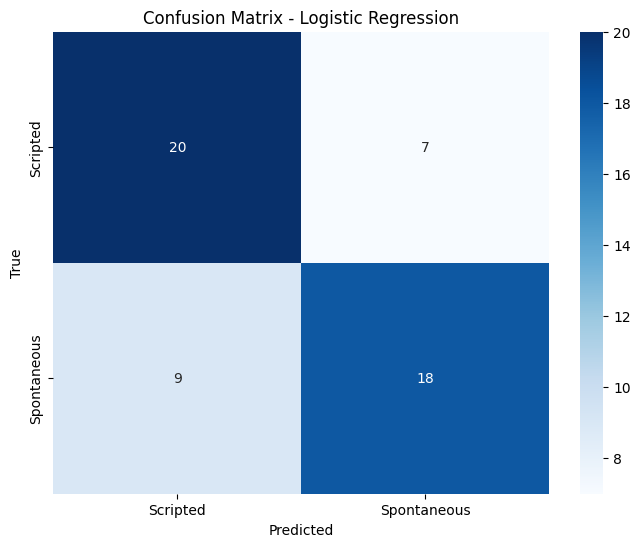

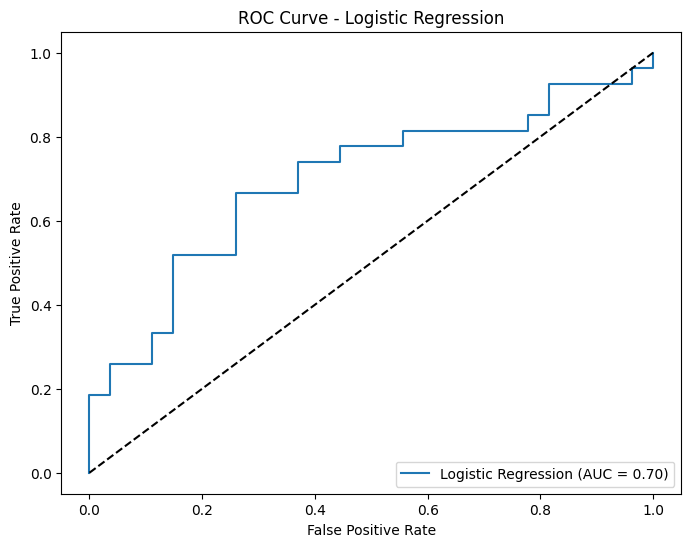

Cross-Validation Accuracy: 0.70 ± 0.08
Final model trained on the entire dataset.
Model pipeline saved to C:\Users\muham\PycharmProjects\gazelle\models\behavior_classifier_pipeline.joblib
Label encoder saved to C:\Users\muham\PycharmProjects\gazelle\models\label_encoder.joblib


In [21]:
# train_and_save_model.py

import pandas as pd
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress any potential warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

def load_and_merge_data(gaze_features_path, blink_results_path):
    """
    Load gaze_features and blink_results datasets and merge them on 'person_id' and 'label'.
    """
    gaze_features = pd.read_csv(gaze_features_path)
    blink_results = pd.read_csv(blink_results_path)

    # Merge datasets
    merged_data = pd.merge(gaze_features, blink_results, on=['person_id', 'label'], how='inner')
    return merged_data

def encode_labels(merged_data):
    """
    Encode the 'label' column into numerical values.
    """
    le = LabelEncoder()
    merged_data['label_encoded'] = le.fit_transform(merged_data['label'])  # 0: scripted, 1: spontaneous
    return merged_data, le

def define_features_and_target(merged_data):
    """
    Define feature matrix X and target vector y.
    """
    X = merged_data.drop(['person_id', 'label', 'label_encoded'], axis=1)
    y = merged_data['label_encoded']
    return X, y

def create_pipeline():
    """
    Create a machine learning pipeline that includes feature selection, scaling, and classification.
    """
    pipeline = Pipeline([
        ('feature_selection', SelectKBest(score_func=f_classif, k=15)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42))
    ])
    return pipeline

def evaluate_model(pipeline, X, y, skf):
    """
    Evaluate the model using cross-validation and display performance metrics.
    """
    # Cross-validated predictions
    y_pred = cross_val_predict(pipeline, X, y, cv=skf)

    # Classification Report
    print("Classification Report:")
    print(classification_report(y, y_pred, target_names=['Scripted', 'Spontaneous']))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Scripted', 'Spontaneous'],
                yticklabels=['Scripted', 'Spontaneous'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Logistic Regression')
    plt.show()

    # ROC Curve and AUC
    y_scores = cross_val_predict(pipeline, X, y, cv=skf, method='decision_function')
    auc = roc_auc_score(y, y_scores)
    fpr, tpr, thresholds = roc_curve(y, y_scores)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Logistic Regression')
    plt.legend(loc='lower right')
    plt.show()

    # Cross-validation Accuracy
    cv_accuracy = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")

def train_final_model(pipeline, X, y):
    """
    Fit the pipeline on the entire dataset.
    """
    pipeline.fit(X, y)
    return pipeline

def save_model(pipeline, label_encoder, model_path, label_encoder_path):
    """
    Save the trained pipeline and label encoder to disk.
    """
    # Ensure the directory exists
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    os.makedirs(os.path.dirname(label_encoder_path), exist_ok=True)

    # Save the pipeline
    joblib.dump(pipeline, model_path)
    print(f"Model pipeline saved to {model_path}")

    # Save the label encoder
    joblib.dump(label_encoder, label_encoder_path)
    print(f"Label encoder saved to {label_encoder_path}")

def main():
    # Define file paths
    gaze_features_path = r"C:\Users\muham\PycharmProjects\gazelle\gaze_output\gaze_features.csv"
    blink_results_path = r"C:\Users\muham\PycharmProjects\gazelle\scripts\blink_results.csv"

    # Load and merge data
    merged_data = load_and_merge_data(gaze_features_path, blink_results_path)

    # Encode labels
    merged_data, le = encode_labels(merged_data)

    # Define features and target
    X, y = define_features_and_target(merged_data)

    # Create machine learning pipeline
    pipeline = create_pipeline()

    # Define cross-validation strategy
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Evaluate the model
    evaluate_model(pipeline, X, y, skf)

    # Train the final model on the entire dataset
    final_model = train_final_model(pipeline, X, y)
    print("Final model trained on the entire dataset.")

    # Define paths to save the model and label encoder
    model_path = r"C:\Users\muham\PycharmProjects\gazelle\models\behavior_classifier_pipeline.joblib"
    label_encoder_path = r"C:\Users\muham\PycharmProjects\gazelle\models\label_encoder.joblib"

    # Save the model and label encoder
    save_model(final_model, le, model_path, label_encoder_path)

if __name__ == "__main__":
    main()
